<a href="https://colab.research.google.com/github/Harkt192/YaML-Deepfake/blob/Harkt/optimizer_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
from torch.utils.data import DataLoader

from tqdm import tqdm
from tqdm.notebook import tqdm
from sklearn.metrics import f1_score, roc_auc_score

In [ ]:
def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(42)

In [ ]:
!pip install gdown

In [ ]:
!gdown 174y9Ef5Qt5uLDhqZA-2TNSLgKLowVift -O dataset.zip

Downloading...
From (original): https://drive.google.com/uc?id=174y9Ef5Qt5uLDhqZA-2TNSLgKLowVift
From (redirected): https://drive.google.com/uc?id=174y9Ef5Qt5uLDhqZA-2TNSLgKLowVift&confirm=t&uuid=113a203f-5c79-4afd-8bc0-a98457d865fe
To: /content/dataset.zip
100% 2.68G/2.68G [00:25<00:00, 105MB/s]


In [ ]:
!unzip -q dataset.zip -d dataset/

replace dataset/dataset/test_images/0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace dataset/dataset/test_images/1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace dataset/dataset/test_images/10.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
for root, dirs, files in os.walk("dataset"):
    print(root)

dataset
dataset/dataset
dataset/dataset/train_images
dataset/dataset/test_images


In [ ]:
train_dir = "dataset/dataset/train_images"
test_dir = "dataset/dataset/test_images"
csv_dir = "dataset/dataset/train_solution.csv"

In [ ]:
labels = dict()

with open(csv_dir, "r") as file:
    for line in file:
        line = line.strip()
        if "," in line:
            idx, val = line.split(",")
            labels[int(idx)] = int(val)
        else:
            labels[int(line)] = 0

In [ ]:
print(len(os.listdir(train_dir)))
print(len(os.listdir(test_dir)))
len(labels)

50000
10000


50000

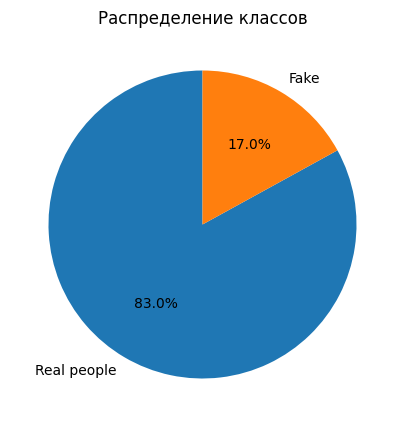

In [ ]:
counter = Counter(labels.values())

label_0 = counter[0]
label_1 = counter[1]

plt.figure(figsize=[10,5])
plt.pie(
    [label_0, label_1],
    labels=["Real people", "Fake"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Распределение классов")
plt.show()

In [ ]:
class DeepfakeDataset(Dataset):
    def __init__(self, img_dir, labels=None, transform=None):
        self.img_dir = img_dir
        self.labels = labels
        self.transform = transform
        self.files = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        img_id = int(fname.split(".")[0])

        img = Image.open(os.path.join(self.img_dir, fname)).convert("RGB")

        if self.transform:
            img = self.transform(img)

        if self.labels is not None:
            label = self.labels[img_id]
            return img, label

        return img, fname

In [ ]:
train_files = sorted(os.listdir(train_dir))

to_tensor = transforms.ToTensor()

mean = torch.zeros(3)
std = torch.zeros(3)

n_pixels = 0

for fname in train_files:
    img_path = os.path.join(train_dir, fname)

    img = Image.open(img_path).convert("RGB")
    img = to_tensor(img)

    c, h, w = img.shape
    n_pixels += h * w

    mean += img.sum(dim=(1, 2))
    std += (img ** 2).sum(dim=(1, 2))

mean /= n_pixels
std = (std / n_pixels - mean ** 2) ** 0.5

print("Mean:", mean)
print("Std:", std)

Mean: tensor([0.5192, 0.4276, 0.3844])
Std: tensor([0.2860, 0.2640, 0.2635])


In [ ]:
transform_rule = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=mean.tolist(),
        std=std.tolist()
    )
])

In [ ]:
from sklearn.model_selection import train_test_split

all_ids = list(labels.keys())
all_labels = [labels[i] for i in all_ids]

train_ids, val_ids = train_test_split(
    all_ids,
    test_size=0.2,
    random_state=42,
    stratify=all_labels
)

In [ ]:
test_files = sorted(os.listdir(test_dir))

In [ ]:
train_dataset = DeepfakeDataset(
    img_dir=train_dir,
    labels=labels,
    transform=transform_rule
)

train_dataset.files = [f"{i}.jpg" for i in train_ids]

In [ ]:
val_dataset = DeepfakeDataset(
    img_dir=train_dir,
    labels=labels,
    transform=transform_rule
)

val_dataset.files = [f"{i}.jpg" for i in val_ids]

In [ ]:
test_dataset = DeepfakeDataset(
    img_dir=test_dir,
    labels=None,
    transform=transform_rule
)

test_dataset.files = test_files

In [ ]:
def seed_worker(worker_id):
    worker_seed = 42 + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    worker_init_fn=seed_worker,
    generator=g
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    worker_init_fn=seed_worker
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

In [ ]:
vis_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor()
])

vis_dataset = DeepfakeDataset(
    img_dir=train_dir,
    labels=labels,
    transform=vis_transform
)

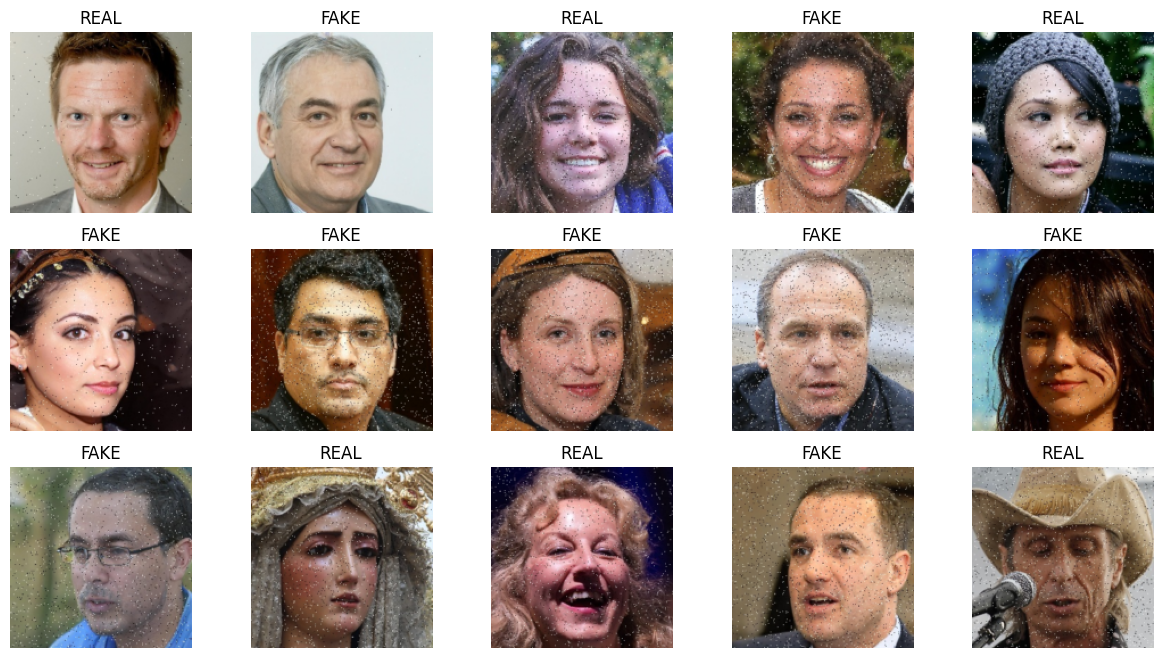

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

for i in range(15):
    img, label = vis_dataset[i]

    plt.subplot(3, 5, i+1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title("FAKE" if label == 1 else "REAL")
    plt.axis("off")

plt.show()

In [ ]:
def train(model, dataloader, optimizer, loss_func, device):
    model.train()

    total_loss = 0.0

    preds = []
    targets = []
    probs_all = []

    for X, y in dataloader:
        X = X.to(device, non_blocking=True)
        y = y.float().to(device).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type='cuda'):
            output = model(X)
            loss = loss_func(output, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        probs = torch.sigmoid(output).detach()

        preds.append((probs > 0.5).long().cpu())
        targets.append(y.long().cpu())
        probs_all.append(probs.cpu())

    preds = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()
    probs_all = torch.cat(probs_all).numpy()

    f1 = f1_score(targets, preds, average='binary')
    roc_auc = roc_auc_score(targets, probs_all)

    return total_loss / len(dataloader), f1, roc_auc

In [ ]:
@torch.no_grad()
def evaluate(model, dataloader, loss_func, device):
    model.eval()

    total_loss = 0.0

    preds = []
    targets = []
    probs_all = []

    for X, y in dataloader:
        X = X.to(device, non_blocking=True)
        y = y.float().to(device).unsqueeze(1)

        output = model(X)
        loss = loss_func(output, y)

        total_loss += loss.item()

        probs = torch.sigmoid(output)

        preds.append((probs > 0.5).long().cpu())
        targets.append(y.long().cpu())
        probs_all.append(probs.cpu())

    preds = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()
    probs_all = torch.cat(probs_all).numpy()

    f1 = f1_score(targets, preds, average='binary')
    roc_auc = roc_auc_score(targets, probs_all)

    return total_loss / len(dataloader), f1, roc_auc

In [ ]:
def fit(model, train_loader, val_loader, optimizer, loss_func, device, epochs, scheduler):

    scaler = torch.cuda.amp.GradScaler()

    train_losses, val_losses = [], []
    train_f1s, val_f1s = [], []
    train_aucs, val_aucs = [], []

    for epoch in range(1, epochs + 1):

        train_loss, train_f1, train_auc = train(
            model, train_loader, optimizer, loss_func, device
        )

        val_loss, val_f1, val_auc = evaluate(
            model, val_loader, loss_func, device
        )

        scheduler.step(val_loss)

        print(f"\nEpoch {epoch}")
        print(f"Train loss {train_loss:.4f} | F1 {train_f1:.4f} | AUC {train_auc:.4f}")
        print(f"Val   loss {val_loss:.4f} | F1 {val_f1:.4f} | AUC {val_auc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_f1s.append(train_f1)
        val_f1s.append(val_f1)

        train_aucs.append(train_auc)
        val_aucs.append(val_auc)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

    ax1.plot(train_losses, label="Train")
    ax1.plot(val_losses, label="Val")
    ax1.set_title("Loss")
    ax1.legend()
    ax1.grid()

    ax2.plot(train_aucs, label="Train AUC")
    ax2.plot(val_aucs, label="Val AUC")
    ax2.set_title("ROC-AUC")
    ax2.legend()
    ax2.grid()

    plt.show()

In [ ]:
def plot_func(train_loss_list, test_loss_list, train_metrics_list, test_metrics_list):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

    ax1.plot(train_loss_list, label='Train Loss')
    ax1.plot(test_loss_list, label='Valid Loss')
    ax1.set_title('Loss')
    ax1.legend()
    ax1.grid()

    ax2.plot(train_metrics_list, label='Train F1')
    ax2.plot(test_metrics_list, label='Valid F1')
    ax2.set_title('F1-score')
    ax2.legend()
    ax2.grid()

    plt.show()

In [ ]:
class DeepfakeCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DeepfakeCNN().to(device)
model = torch.compile(model)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5
)

pos_weight = torch.tensor([counter[0] / counter[1]]).to(device)

loss_func = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

scaler = torch.cuda.amp.GradScaler('cuda')

/tmp/ipykernel_26286/3518269211.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler('cuda')


In [ ]:
fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    loss_func,
    device,
    epochs=10,
    scheduler=scheduler
)

/tmp/ipykernel_26286/4065167102.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
import torch
print(torch.__version__)

2.10.0+cu128
